# QAWG experiment compiler demo

This notebook demonstrates the unified host-side compiler without requiring
hardware for the preview sections.

Included examples:

1. Pulse-probe spectroscopy frequency sequence.
2. Power Rabi gain sequence.
3. T1 delay sequence.
4. Single-shot ground/excited sequence.
5. Optional AWG5208 + ATS9371 acquisition using `n_average`.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from QAWG import (
    MHz,
    PowerRabiProgram,
    PulseProbeSpectroscopyProgram,
    SingleShotProgram,
    T1Program,
    ns,
    us,
)

## Shared configuration

In [39]:
SAMPLE_RATE_HZ = 2.5e9

base_cfg = {
    "qubit_ch": 4,
    "res_ch": 3,
    "marker_ch": 1,
    "adc_channel": "CHA",
    "f_ge": 100 * MHz,
    "f_res": 50 * MHz,
    "res_len": 1 * us,
    "res_gain": 0.02,
    "ro_len": 1 * us,
}

## Pulse-probe spectroscopy

In [40]:
spectroscopy_cfg = {
    **base_cfg,
    "frequency_start": 80 * MHz,
    "frequency_stop": 120 * MHz,
    "steps": 21,
    "probe_len": 500 * ns,
    "qubit_gain": 0.02,
    "trig_time": 0,
}

spectroscopy = PulseProbeSpectroscopyProgram(spectroscopy_cfg)
spectroscopy_compiled = spectroscopy.compile(
    sample_rate_hz=SAMPLE_RATE_HZ,
)

print("Sequence steps:", spectroscopy_compiled.number_of_sequence_steps)
print(
    "Frequency axis (MHz):",
    spectroscopy_compiled.axis("frequency") / MHz,
)

Sequence steps: 21
Frequency axis (MHz): [ 80.  82.  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106.
 108. 110. 112. 114. 116. 118. 120.]


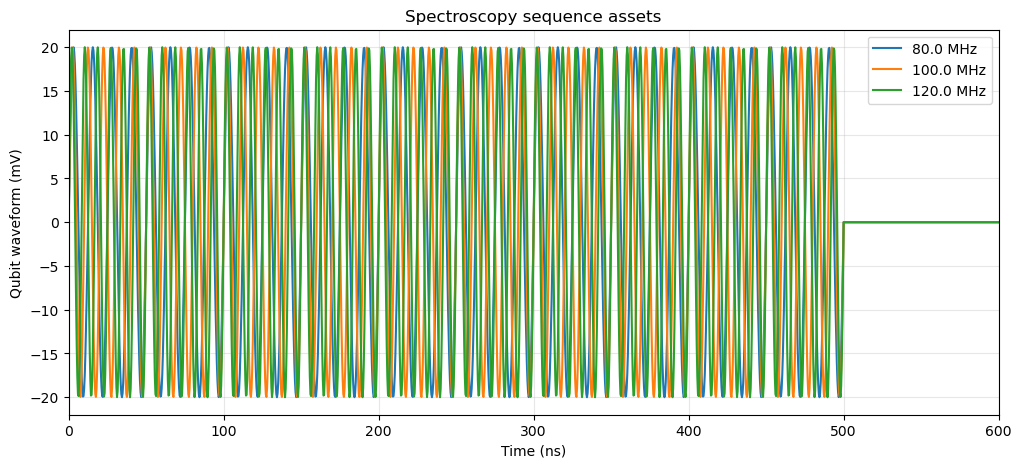

In [41]:
time_ns = (
    np.arange(spectroscopy_compiled.preview(4).shape[1])
    / SAMPLE_RATE_HZ
    / ns
)

plt.figure(figsize=(12, 5))
for index in [0, 10, 20]:
    plt.plot(
        time_ns,
        spectroscopy_compiled.preview(4)[index] * 1e3,
        label=(
            f"{spectroscopy_compiled.axis('frequency')[index] / MHz:.1f} MHz"
        ),
    )
plt.xlim(0, 600)
plt.xlabel("Time (ns)")
plt.ylabel("Qubit waveform (mV)")
plt.title("Spectroscopy sequence assets")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Power Rabi: sequence list changes gain

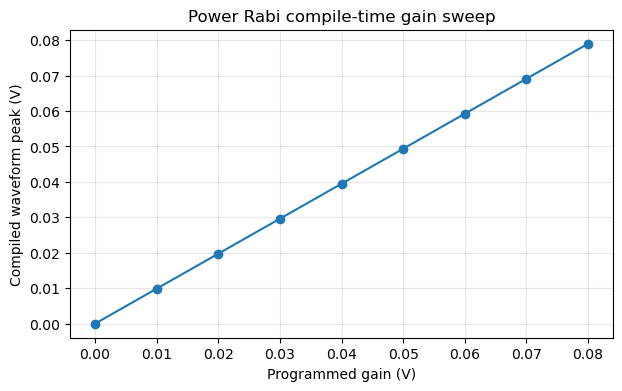

In [42]:
power_rabi_cfg = {
    **base_cfg,
    "gain_start": 0.0,
    "gain_stop": 0.08,
    "steps": 9,
    "qubit_len": 100 * ns,
    "qubit_sigma": 15 * ns,
}

power_rabi = PowerRabiProgram(power_rabi_cfg)
power_rabi_compiled = power_rabi.compile(
    sample_rate_hz=SAMPLE_RATE_HZ,
)

gain = power_rabi_compiled.axis("gain")
peak = np.max(np.abs(power_rabi_compiled.preview(4)), axis=1)

plt.figure(figsize=(7, 4))
plt.plot(gain, peak, "o-")
plt.xlabel("Programmed gain (V)")
plt.ylabel("Compiled waveform peak (V)")
plt.title("Power Rabi compile-time gain sweep")
plt.grid(True, alpha=0.3)
plt.show()

## T1: delay_auto sweep

In [43]:
t1_cfg = {
    **base_cfg,
    "delay_start": 0,
    "delay_stop": 2 * us,
    "steps": 11,
    "pi_len": 100 * ns,
    "pi_sigma": 15 * ns,
    "pi_gain": 0.04,
}

t1 = T1Program(t1_cfg)
t1_compiled = t1.compile(sample_rate_hz=SAMPLE_RATE_HZ)

print("Delay axis (us):", t1_compiled.axis("delay") / us)
print("Fixed step duration (us):", t1_compiled.step_duration_s / us)

Delay axis (us): [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2. ]
Fixed step duration (us): 4.1


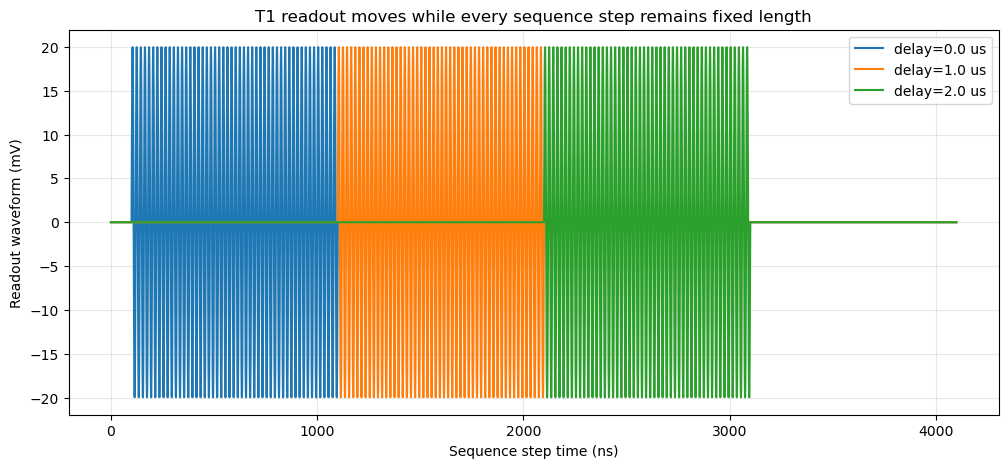

In [44]:
time_ns = np.arange(t1_compiled.preview(3).shape[1]) / SAMPLE_RATE_HZ / ns

plt.figure(figsize=(12, 5))
for index in [0, 5, 10]:
    plt.plot(
        time_ns,
        t1_compiled.preview(3)[index] * 1e3,
        label=f"delay={t1_compiled.axis('delay')[index] / us:.1f} us",
    )
plt.xlabel("Sequence step time (ns)")
plt.ylabel("Readout waveform (mV)")
plt.title("T1 readout moves while every sequence step remains fixed length")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Single-shot ground/excited sequence

In [45]:
single_shot_cfg = {
    **base_cfg,
    "pi_len": 100 * ns,
    "pi_sigma": 15 * ns,
    "pi_gain": 0.04,
}

single_shot = SingleShotProgram(single_shot_cfg)
single_shot_compiled = single_shot.compile(
    sample_rate_hz=SAMPLE_RATE_HZ,
)

print("State axis:", single_shot_compiled.axis("state"))
print(
    "Ground qubit peak:",
    np.max(np.abs(single_shot_compiled.preview(4)[0])),
)
print(
    "Excited qubit peak:",
    np.max(np.abs(single_shot_compiled.preview(4)[1])),
)

State axis: ['g' 'e']
Ground qubit peak: 0.0
Excited qubit peak: 0.03949399667801031


## Hardware TOF loopback test

Connect the selected AWG output directly to the selected ATS9371 input.

The Gaussian-square pulse and Alazar marker are both scheduled at `t=0`.
Therefore the measured pulse arrival time is the total loopback time of flight
through the AWG output path, cable, and ATS acquisition path.

Run the following three cells in order.

In [46]:
from QAWG import ExperimentProgram, ns, us


class TOFProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "loopback",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "tof_pulse",
            gen="loopback",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["pulse_gain"],
        )

    def _body(self, cfg):
        # The marker is derived from tof_pulse on waveform_ch.
        self.play("tof_pulse", at=0)
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )

In [47]:
from QAWG import AWGAlazar, MHz, ns, us

# Physical loopback:
# AWG channel 3 analog output -> ATS9371 CHB input
# AWG marker channel 1 marker 1 -> ATS9371 external trigger
tof_cfg = {
    "awg_ch": 3,
    "marker_ch": 1,
    "adc_channel": "CHB",
    "channel_amplitude_vpp": 0.5,
    "frequency": 50 * MHz,
    "pulse_length": 600 * ns,
    "edge_sigma": 20 * ns,
    "pulse_gain": 0.02,
    "acquire_length": 1.5 * us,
    "trigger_delay": 0,
    "integrate_time": 1 * us,
}

TOF_N_AVERAGE = 1000
HARDWARE_ACQUIRE_WINDOW = 1.5 * us

experiment = AWGAlazar.connect(
    "TCPIP0::192.168.10.171::inst0::INSTR",
    awg_sample_rate_hz=2.5e9,
    alazar_sample_rate_hz=1e9,
    acquire_window_s=HARDWARE_ACQUIRE_WINDOW,
    trigger_slope="rising",
    trigger_level=140,
)

tof_program = TOFProgram(tof_cfg, final_delay_s=1 * us)
tof_compiled = tof_program.compile(hardware=experiment)

print("Sequence steps:", tof_compiled.number_of_sequence_steps)
print("AWG step duration (us):", tof_compiled.step_duration_s / us)
print("ATS trigger delay: 0 ns")

Sequence steps: 1
AWG step duration (us): 2.5000000000000004
ATS trigger delay: 0 ns


Estimated loopback TOF: 89.777 ns


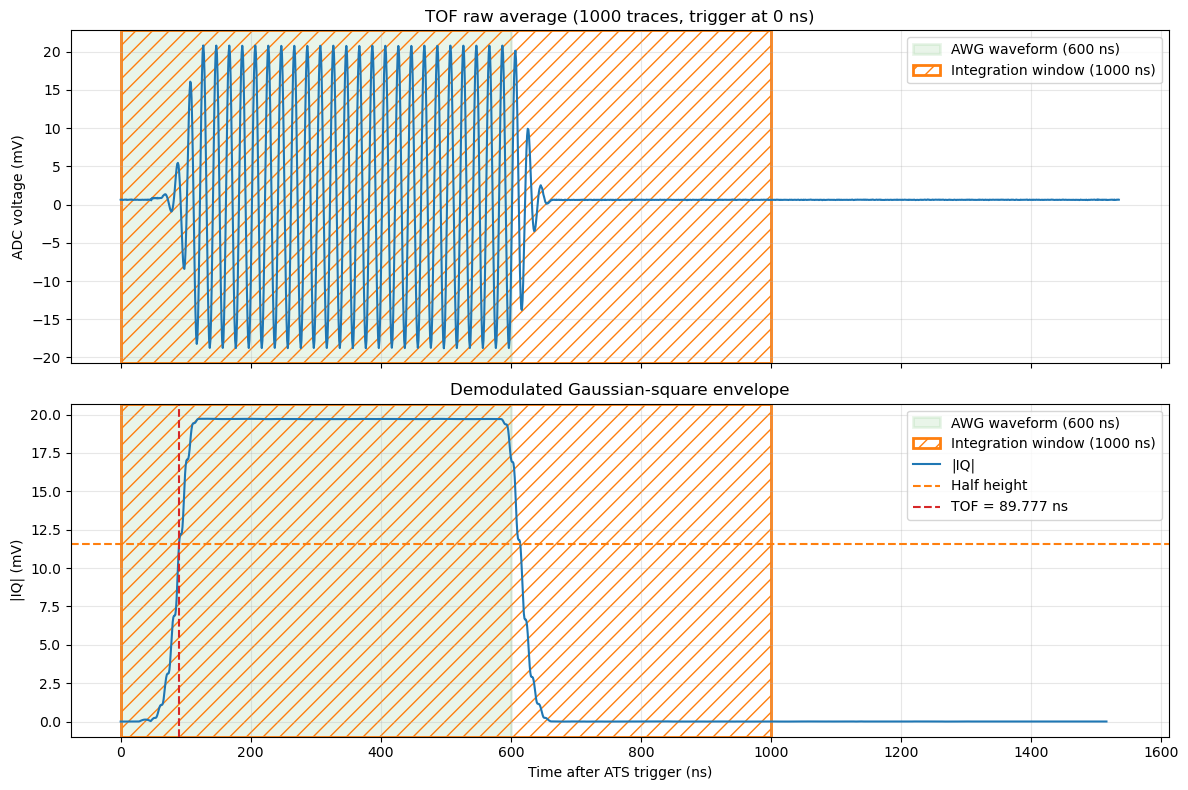

In [48]:
import numpy as np
import matplotlib.pyplot as plt

tof_result = tof_compiled.acquire(n_average=TOF_N_AVERAGE)

raw_average_mv = tof_result.trace_average("ro")[0] * 1e3
iq_envelope_mv = np.abs(tof_result.iq_trace_average("ro")[0]) * 1e3
raw_time_ns = tof_result.raw_time_s / ns
iq_time_ns = tof_result.iq_time_s / ns

awg_start_ns = -tof_cfg["trigger_delay"] / ns
awg_stop_ns = awg_start_ns + tof_cfg["pulse_length"] / ns
integration_start_ns = 0.0
integration_stop_ns = tof_cfg["integrate_time"] / ns

# Estimate arrival from the IQ envelope's rising half-height crossing.
baseline_samples = max(1, int(0.1 * iq_envelope_mv.size))
baseline_mv = np.median(iq_envelope_mv[:baseline_samples])
peak_mv = np.percentile(iq_envelope_mv, 95)
half_height_mv = baseline_mv + 0.5 * (peak_mv - baseline_mv)
crossings = np.flatnonzero(iq_envelope_mv >= half_height_mv)

if crossings.size:
    right = crossings[0]
    if right == 0:
        tof_ns = iq_time_ns[0]
    else:
        left = right - 1
        y0, y1 = iq_envelope_mv[left], iq_envelope_mv[right]
        fraction = (
            0.0 if y1 == y0
            else (half_height_mv - y0) / (y1 - y0)
        )
        tof_ns = iq_time_ns[left] + fraction * (
            iq_time_ns[right] - iq_time_ns[left]
        )
    print(f"Estimated loopback TOF: {tof_ns:.3f} ns")
else:
    tof_ns = np.nan
    print("No pulse crossing found. Check loopback wiring and signal level.")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(raw_time_ns, raw_average_mv)
for axis in axes:
    axis.axvspan(
        awg_start_ns,
        awg_stop_ns,
        facecolor="tab:green",
        alpha=0.10,
        edgecolor="tab:green",
        linewidth=2,
        label=f"AWG waveform ({awg_stop_ns - awg_start_ns:.0f} ns)",
    )
    axis.axvspan(
        integration_start_ns,
        integration_stop_ns,
        facecolor="none",
        edgecolor="tab:orange",
        linewidth=2,
        hatch="//",
        label=(
            "Integration window "
            f"({integration_stop_ns - integration_start_ns:.0f} ns)"
        ),
    )
axes[0].set_ylabel("ADC voltage (mV)")
axes[0].set_title(
    f"TOF raw average ({TOF_N_AVERAGE} traces, trigger at 0 ns)"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iq_time_ns, iq_envelope_mv, label="|IQ|")
axes[1].axhline(
    half_height_mv,
    color="tab:orange",
    linestyle="--",
    label="Half height",
)
if np.isfinite(tof_ns):
    axes[1].axvline(
        tof_ns,
        color="tab:red",
        linestyle="--",
        label=f"TOF = {tof_ns:.3f} ns",
    )
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("|IQ| (mV)")
axes[1].set_title("Demodulated Gaussian-square envelope")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Hardware Gaussian-square length sweep

This sequence changes the AWG Gaussian-square pulse length from 100 ns to
600 ns. The ATS trigger remains fixed at `t=0`.

`compiled.acquire()` keeps every decimated IQ trace with shape
`(n_average, sequence_step, time)`. Calling `iq_trace_average("ro")` averages
matching records trace by trace, so the changing pulse width remains visible.

In [49]:
from QAWG import ExperimentProgram, LinearSweep, ns


class LengthSweepProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "loopback",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            integrate_time=cfg["integrate_time"],
        )
        pulse_length = self.add_sweep(
            "pulse_length",
            LinearSweep(
                cfg["length_start"],
                cfg["length_stop"],
                cfg["length_steps"],
            ),
        )
        self.add_pulse(
            "length_sweep_pulse",
            gen="loopback",
            style="gaussian_square",
            length=pulse_length,
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["pulse_gain"],
        )

    def _body(self, cfg):
        self.play("length_sweep_pulse", at=0)
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )

Pulse lengths (ns): [100. 200. 300. 400. 500. 600.]
All decimated IQ traces: (500, 6, 1517)
Trace-by-trace average: (6, 1517)


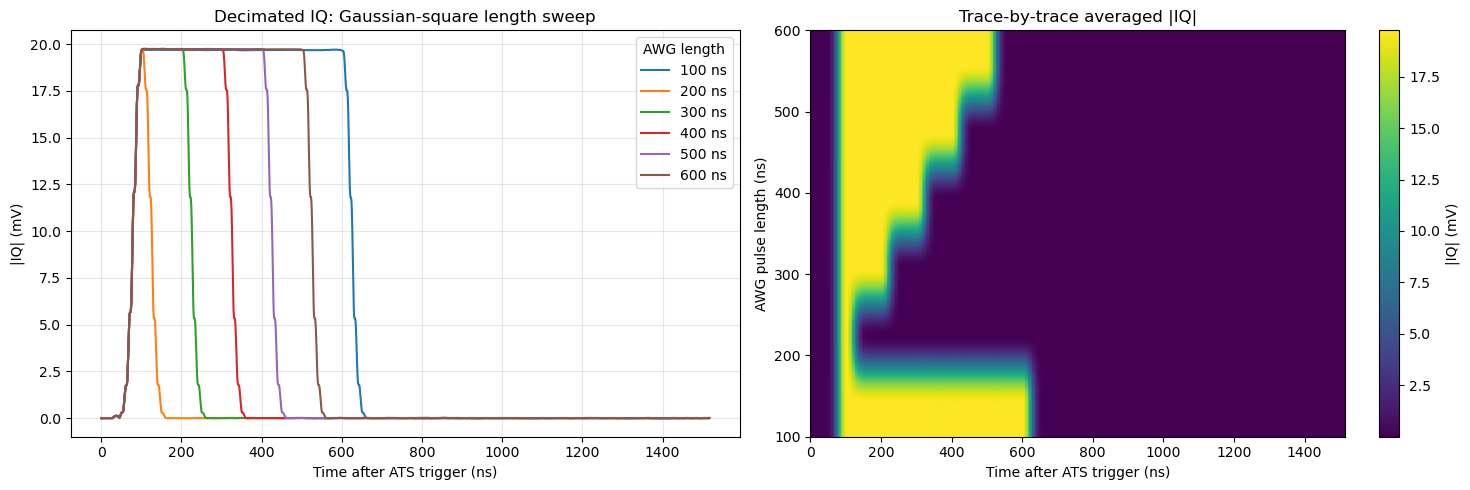

In [50]:
length_sweep_cfg = {
    **tof_cfg,
    "length_start": 100 * ns,
    "length_stop": 600 * ns,
    "length_steps": 6,
    "edge_sigma": 15 * ns,
}
LENGTH_SWEEP_N_AVERAGE = 500

length_program = LengthSweepProgram(
    length_sweep_cfg,
    final_delay_s=1 * us,
)
length_compiled = length_program.compile(hardware=experiment)
length_result = length_compiled.acquire(
    n_average=LENGTH_SWEEP_N_AVERAGE,
    filter_type="boxcar",
)

length_ns = length_result.axis("pulse_length") / ns
length_iq_mv = np.abs(length_result.iq_trace_average("ro")) * 1e3
length_time_ns = length_result.iq_time_s / ns

print("Pulse lengths (ns):", length_ns)
print("All decimated IQ traces:", length_result.iq_traces.shape)
print("Trace-by-trace average:", length_iq_mv.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for index, pulse_length_ns in enumerate(length_ns):
    axes[0].plot(
        length_time_ns,
        length_iq_mv[index],
        label=f"{pulse_length_ns:.0f} ns",
    )
axes[0].set_xlabel("Time after ATS trigger (ns)")
axes[0].set_ylabel("|IQ| (mV)")
axes[0].set_title("Decimated IQ: Gaussian-square length sweep")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="AWG length")

image = axes[1].imshow(
    length_iq_mv,
    aspect="auto",
    origin="lower",
    extent=[
        length_time_ns[0],
        length_time_ns[-1],
        length_ns[0],
        length_ns[-1],
    ],
)
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("AWG pulse length (ns)")
axes[1].set_title("Trace-by-trace averaged |IQ|")
fig.colorbar(image, ax=axes[1], label="|IQ| (mV)")

plt.tight_layout()
plt.show()

## Hardware `delay_auto` sweep

Every sequence step uses the same 100 ns Gaussian pulse. Only the relative
delay before the pulse changes:

```text
delay_auto(0 ns)   / Gaussian
delay_auto(40 ns)  / Gaussian
...
delay_auto(200 ns) / Gaussian
```

The ATS trigger stays at `t=0`, so the decimated traces show the waveform
moving later inside the same acquisition window.

In [51]:
class DelayAutoSweepProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "loopback",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            marker_channel=cfg["marker_ch"],
            marker_length=cfg["marker_length"],
            integrate_time=cfg["integrate_time"],
        )
        self.delay = self.add_sweep(
            "delay",
            LinearSweep(
                cfg["delay_start"],
                cfg["delay_stop"],
                cfg["delay_steps"],
            ),
        )
        self.add_pulse(
            "delayed_gaussian",
            gen="loopback",
            style="gaussian",
            length=cfg["gaussian_length"],
            sigma=cfg["gaussian_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["pulse_gain"],
        )

    def _body(self, cfg):
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )
        self.delay_auto(self.delay)
        self.play("delayed_gaussian")

delay_auto values (ns): [  0.  40.  80. 120. 160. 200.]
All decimated IQ traces: (500, 6, 1517)
Trace-by-trace average: (6, 1517)


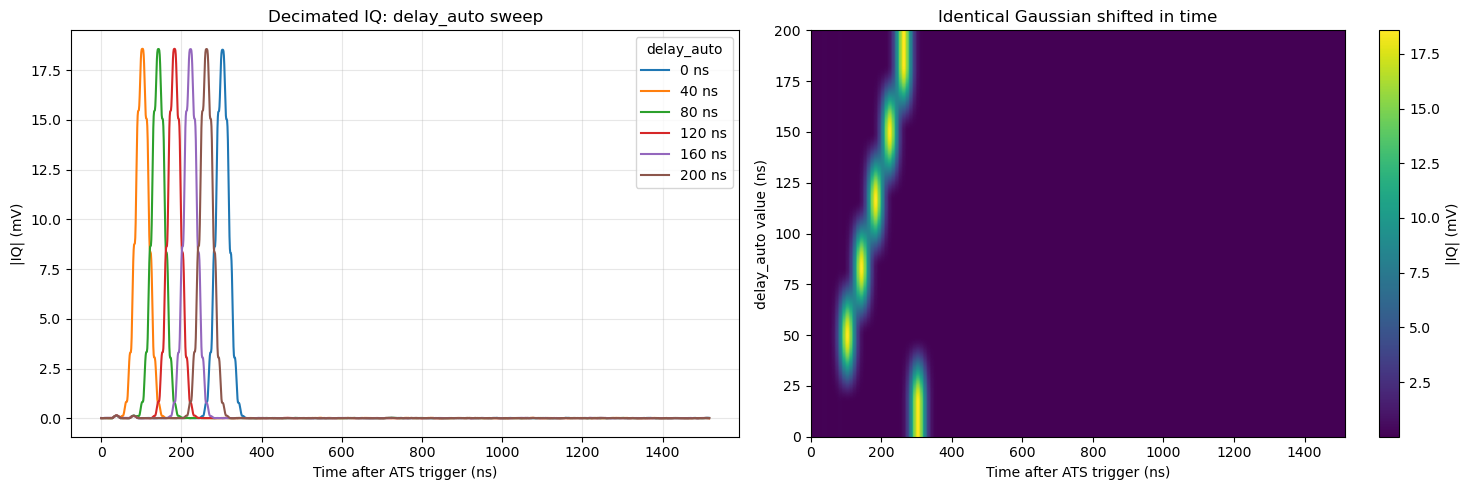

In [52]:
delay_sweep_cfg = {
    **tof_cfg,
    "marker_length": 40 * ns,
    "delay_start": 0 * ns,
    "delay_stop": 200 * ns,
    "delay_steps": 6,
    "gaussian_length": 100 * ns,
    "gaussian_sigma": 15 * ns,
}
DELAY_SWEEP_N_AVERAGE = 500

delay_program = DelayAutoSweepProgram(
    delay_sweep_cfg,
    final_delay_s=1 * us,
)
delay_compiled = delay_program.compile(hardware=experiment)
delay_result = delay_compiled.acquire(
    n_average=DELAY_SWEEP_N_AVERAGE,
    filter_type="boxcar",
)

delay_ns = delay_result.axis("delay") / ns
delay_iq_mv = np.abs(delay_result.iq_trace_average("ro")) * 1e3
delay_time_ns = delay_result.iq_time_s / ns

print("delay_auto values (ns):", delay_ns)
print("All decimated IQ traces:", delay_result.iq_traces.shape)
print("Trace-by-trace average:", delay_iq_mv.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for index, delay_value_ns in enumerate(delay_ns):
    axes[0].plot(
        delay_time_ns,
        delay_iq_mv[index],
        label=f"{delay_value_ns:.0f} ns",
    )
axes[0].set_xlabel("Time after ATS trigger (ns)")
axes[0].set_ylabel("|IQ| (mV)")
axes[0].set_title("Decimated IQ: delay_auto sweep")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="delay_auto")

image = axes[1].imshow(
    delay_iq_mv,
    aspect="auto",
    origin="lower",
    extent=[
        delay_time_ns[0],
        delay_time_ns[-1],
        delay_ns[0],
        delay_ns[-1],
    ],
)
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("delay_auto value (ns)")
axes[1].set_title("Identical Gaussian shifted in time")
fig.colorbar(image, ax=axes[1], label="|IQ| (mV)")

plt.tight_layout()
plt.show()

## Hardware single shot: 0 and 180 degree readout

This sequence contains two readout steps with exactly the same waveform
length, frequency, and amplitude. Only the carrier phase changes:

```text
step 0: readout phase =   0 degrees
step 1: readout phase = 180 degrees
```

The waveform length equals the declared readout length. Every acquisition is
kept as an individual shot.

In [53]:
from QAWG import ExperimentProgram, ValuesSweep


class PhaseSingleShotProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["readout_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["readout_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["readout_ch"],
            marker_channel=cfg["marker_ch"],
            integrate_time=cfg["readout_length"],
        )
        phase = self.add_sweep(
            "phase",
            ValuesSweep((0.0, np.pi)),
        )
        self.add_pulse(
            "readout_pulse",
            gen="readout",
            style="const",
            length=cfg["readout_length"],
            frequency=cfg["frequency"],
            phase=phase,
            gain=cfg["readout_gain"],
        )

    def _body(self, cfg):
        self.play("readout_pulse", at=0)
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )

In [56]:
phase_single_shot_cfg = {
    "readout_ch": tof_cfg["awg_ch"],
    "marker_ch": tof_cfg["marker_ch"],
    "adc_channel": tof_cfg["adc_channel"],
    "channel_amplitude_vpp": tof_cfg["channel_amplitude_vpp"],
    "frequency": tof_cfg["frequency"],
    "readout_length": 1 * us,
    "readout_gain": 0.00005,
    "trigger_delay": tof_cfg["trigger_delay"],
}
SINGLE_SHOT_N_AVERAGE = 1000

phase_single_shot = PhaseSingleShotProgram(
    phase_single_shot_cfg,
    final_delay_s=1 * us,
)
phase_single_shot_compiled = phase_single_shot.compile(
    hardware=experiment,
)
phase_single_shot_result = phase_single_shot_compiled.acquire(
    n_average=SINGLE_SHOT_N_AVERAGE,
    filter_type="boxcar",
)

phase_degrees = np.rad2deg(
    phase_single_shot_result.axis("phase")
)
print("Phase steps (degrees):", phase_degrees)
print(
    "Raw records (shot, phase, time):",
    phase_single_shot_result.raw.shape,
)

Phase steps (degrees): [  0. 180.]
Raw records (shot, phase, time): (1000, 2, 1536)


### Trajectory from raw downconverted data

The calculation below starts from the unfiltered ADC voltage records. It
performs complex digital downconversion and then computes the cumulative IQ
average independently for every shot:

```python
trajectory[..., n] = mean(raw_downconverted[..., :n + 1])
```

No averaging between shots is performed before constructing the trajectories.

Raw downconverted IQ (shot, phase, time): (1000, 2, 1000)
IQ trajectory: (1000, 2, 1000)
Trajectory integration stop: 1000 ns (physical readout length)


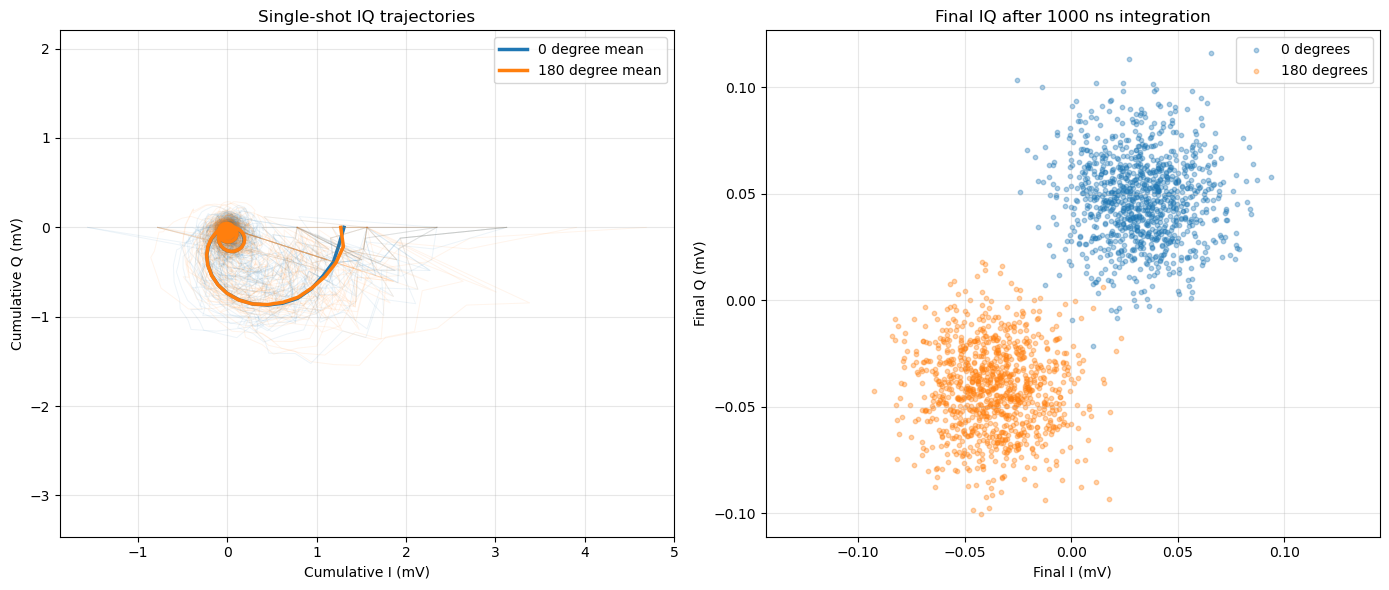

In [57]:
raw_records = phase_single_shot_result.raw
raw_time_s = phase_single_shot_result.raw_time_s
frequency_hz = phase_single_shot_cfg["frequency"]
readout_samples = int(round(
    phase_single_shot_cfg["readout_length"]
    * experiment.alazar_sample_rate_hz
))

# ATS record length is aligned to the hardware block size. Do not integrate
# the zero-padded tail after the physical readout waveform has ended.
raw_records = raw_records[:, :, :readout_samples]
raw_time_s = raw_time_s[:readout_samples]

# Same convention as QAWG.alazar.digital_downconvert(), without filtering.
digital_reference = np.exp(
    -1j * 2 * np.pi * frequency_hz * raw_time_s
)
raw_downconverted = 2.0 * raw_records * digital_reference[None, None, :]

sample_count = np.arange(
    1,
    raw_downconverted.shape[2] + 1,
    dtype=float,
)
trajectory = np.cumsum(raw_downconverted, axis=2)
trajectory /= sample_count[None, None, :]

integration_time_ns = sample_count / experiment.alazar_sample_rate_hz / ns
final_iq_mv = trajectory[:, :, -1] * 1e3

print(
    "Raw downconverted IQ (shot, phase, time):",
    raw_downconverted.shape,
)
print("IQ trajectory:", trajectory.shape)
print(
    "Trajectory integration stop:",
    f"{integration_time_ns[-1]:.0f} ns "
    "(physical readout length)",
)

colors = ["tab:blue", "tab:orange"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot a readable subset of individual trajectories plus the shot mean.
shots_to_plot = min(50, SINGLE_SHOT_N_AVERAGE)
trajectory_mv = trajectory * 1e3
for phase_index, phase_degree in enumerate(phase_degrees):
    for shot_index in range(shots_to_plot):
        axes[0].plot(
            trajectory_mv[shot_index, phase_index].real,
            trajectory_mv[shot_index, phase_index].imag,
            color=colors[phase_index],
            alpha=0.08,
            linewidth=0.7,
        )
    mean_trajectory = np.mean(
        trajectory_mv[:, phase_index],
        axis=0,
    )
    axes[0].plot(
        mean_trajectory.real,
        mean_trajectory.imag,
        color=colors[phase_index],
        linewidth=2.5,
        label=f"{phase_degree:.0f} degree mean",
    )

    axes[1].scatter(
        final_iq_mv[:, phase_index].real,
        final_iq_mv[:, phase_index].imag,
        s=10,
        alpha=0.35,
        color=colors[phase_index],
        label=f"{phase_degree:.0f} degrees",
    )

axes[0].set_xlabel("Cumulative I (mV)")
axes[0].set_ylabel("Cumulative Q (mV)")
axes[0].set_title("Single-shot IQ trajectories")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Final I (mV)")
axes[1].set_ylabel("Final Q (mV)")
axes[1].set_title(
    f"Final IQ after {integration_time_ns[-1]:.0f} ns integration"
)
axes[1].axis("equal")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()